<a href="https://colab.research.google.com/github/guilhermef2k/Sistemas_Inteligentes/blob/main/regressao_logistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2º Projeto - Sistemas inteligentes
Autores: <br>
Alex Bruno Duarte <br>
Guilherme de França Vasconcelos

## 1. Introdução
---

As doenças cardiovasculares são a principal causa de morte no mundo, responsáveis por cerca de 18 milhões de óbitos por ano, segundo a OMS. O diagnóstico precoce é determinante para o sucesso do tratamento. Existe, portanto, uma necessidade real de ferramentas capazes de estimar o risco de um paciente com base em dados clínicos simples, coletados em consulta de rotina. É nesse contexto que o aprendizado de máquina pode contribuir. Um modelo de classificação treinado com dados históricos de pacientes diagnosticados é capaz de aprender quais combinações de variáveis clínicas estão associadas à presença de doença cardíaca e aplicar esse aprendizado a novos pacientes.

## 2. Objetivo
---

Construir um modelo utilizando Regressão Logística para prever a presença de doença cardíaca com base em um conjunto de dados clínicos.

## 3. Conjunto de dados
---

O projeto utiliza o dataset Heart Disease Cleveland (UCI Machine Learning Repository), com registros de 303 pacientes e 13 variáveis clínicas. Os diagnósticos foram confirmados por cateterismo cardíaco, o que garante rótulos confiáveis. As variáveis incluem:

* age: Idade do paciente em anos.
* sex: Sexo biológico (1 = masculino, 0 = feminino).
* cp: Tipo de dor no peito: angina típica (1), atípica (2), não anginosa (3) ou assintomático (4).
* trestbps: Pressão arterial em repouso em mmHg.
* chol: Colesterol sérico total em mg/dl.
* fbs: Glicemia em jejum acima de 120 mg/dl (1 = sim, 0 = não).
* restecg: Resultado do ECG em repouso: normal (0), alteração na onda ST-T (1) ou hipertrofia ventricular (2).
* thalach: Frequência cardíaca máxima atingida no teste de esforço.
* exang: Angina induzida por exercício (1 = sim, 0 = não).
* oldpeak: Depressão do segmento ST durante o esforço, indicador de isquemia.
* slope: Inclinação do segmento ST no pico do esforço: ascendente (1), plano (2) ou descendente (3).
* ca: Número de artérias coronárias com obstrução visível na fluoroscopia (0 a 3).
* thal: Cintilografia de tálio: normal (3), defeito fixo/infarto prévio (6) ou defeito reversível/isquemia ativa (7).

A variável alvo é a target, que indica o diagnóstico original de 0 a 4, binarizada para 0 (sem doença) e 1 (com doença) antes do treinamento.

## 4. Pré-processamento
---

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import numpy as np

In [2]:
url = 'https://raw.githubusercontent.com/guilhermef2k/Sistemas_Inteligentes/main/Regress%C3%A3o%20Log%C3%ADstica/dataSet/processed.cleveland.data'

# O arquivo não tem cabeçalho, sendo necessária a definição dos nomes das colunas
colunas = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

df = pd.read_csv(url, names=colunas, na_values='?')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


### 4.1. Tratamento de valores nulos

In [3]:
print("Valores nulos antes do tratamento:")
print(df.isnull().sum())

df = df.fillna(df.median())

print("\nValores nulos após o tratamento:")
print(df.isnull().sum())

Valores nulos antes do tratamento:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Valores nulos após o tratamento:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


É possível perceber que somene as culunas *ca* (com 4 valores) e *thal* (com 2 valores) possuiam valores nulos. Apesar disso, o código "*df = df.fillna(df.median())*" faz com que qualquer valor nulo presente em qualquer coluna seja substituido pela mediana. Após essa troca, é visível que não há mais valores nulos em qualquer coluna.

### 4.2. Binárização da variável target

In [4]:
# Valores maiores que 0 tornam-se 1 (True), e 0 permanece 0 (False)
df['target'] = (df['target'] > 0).astype(int)

Dessa forma é feita a binarização da variável target, sendo transformados os valores maiores que 0 em 1 e os valores iguais a 0 mantidos.

### 4.3. Divisão treino/teste

In [7]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

Assim é feita a divisão treino/teste na proporção 80/20 preservando o balanceamento entre as classes.

### 4.4. Escalonamento das features

In [11]:
from sklearn.preprocessing import StandardScaler

cols_continuas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

scaler = StandardScaler()
X_train[cols_continuas] = scaler.fit_transform(X_train[cols_continuas])
X_test[cols_continuas] = scaler.transform(X_test[cols_continuas])

Dessa forma é feita a normalização dos dados

## 5. Treinamento do modelo
---

In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    solver='liblinear',
    random_state=42,
    max_iter=1000,     # máximo de iterações
)

model.fit(X_train, y_train)

n_iteracoes = model.n_iter_[0]
print(f"Número de iterações necessárias para a convergência: {n_iteracoes}")

Número de iterações necessárias para a convergência: 5


## 6. Avaliação do modelo
---

### 6.1. Calculo das métricas: acurácia, precisão, recall e F1-Score

Nesta etapa, validamos a eficácia do classificador de Regressão Logística utilizando o conjunto de teste.

In [20]:
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score
)

y_pred = model.predict(X_test)

print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precisão: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")

Acurácia: 0.8689
Precisão: 0.8125
Recall: 0.9286
F1-Score: 0.8667


* Acurácia (0.8689): O modelo classificou corretamente cerca de 86,8% dos pacientes (tanto saudáveis quanto doentes).

* Precisão (0.8125): Quando o modelo afirma que um paciente possui doença cardíaca, ele está correto em 81,2% das vezes.

* Recall (0.9286):O modelo demonstra uma alta capacidade de identificar pacientes que realmente possuem a doença, minimizando os "falsos negativos" que poderiam deixar um doente sem tratamento.

* F1-Score (0.8667): O modelo mantém um bom equilíbrio entre precisão e recall, sendo uma ferramenta de diagnóstico robusta.

6.2. Curva ROC com valor de AUC.

AUC-ROC:  0.9545


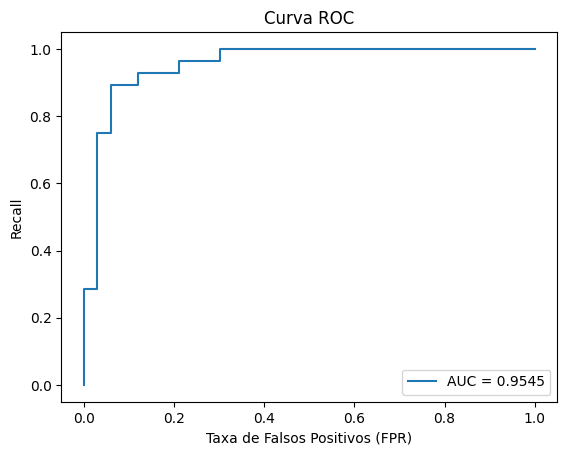

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

print(f"AUC-ROC:  {roc_auc_score(y_test, y_prob):.4f}")

# Plotar
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Recall')
plt.title('Curva ROC')
plt.legend()
plt.show()

* AUC (0.9545): Indica que o modelo possui uma probabilidade muito alta de distinguir corretamente um paciente saudável de um paciente com doença cardíaca.
* A curva acentuada em direção ao canto superior esquerdo demonstra que o modelo atinge um alto índice de verdadeiros positivos rapidamente, com uma taxa mínima de erros de falso alarme

## 7. Conclusão
---

O modelo de Regressão Logística demonstrou ser altamente adequado para prever a presença de doenças cardiovasculares com base em dados clínicos simples. A elevada AUC de 0,9545 e o Recall de 0,9286 confirmam que variáveis como a frequência cardíaca máxima, o número de artérias obstruídas e os resultados de ECG são preditores robustos para o diagnóstico . Portanto, o modelo cumpre o objetivo proposto de oferecer uma ferramenta de triagem precoce eficaz, auxiliando na identificação de pacientes de risco e contribuindo para o sucesso do tratamento clínico.